<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/Zad3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zadatak 3. a)

Accuracy on test set: 0.67


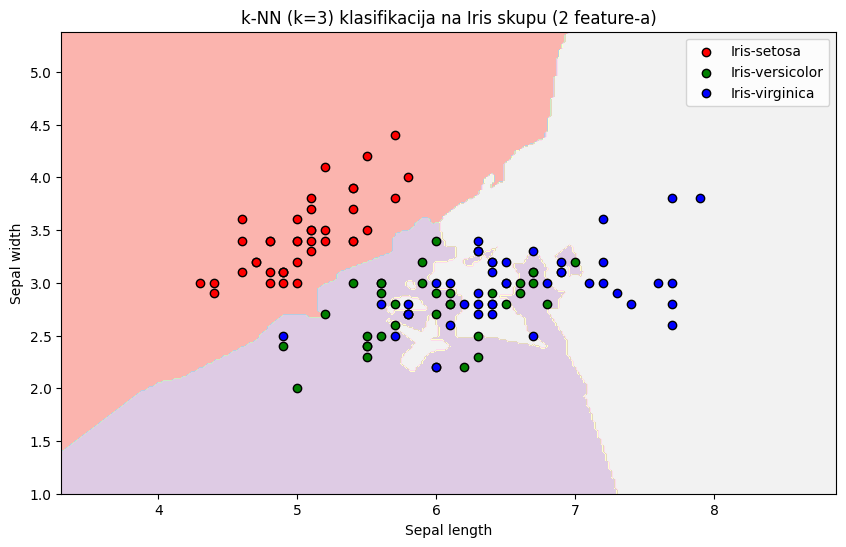

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Učitaj podatke
df = pd.read_csv("iris.csv")

# Pošto je dataset sortiran po vrstama, treba ga pravilno pomešati po vrstama
# Način: uzmi po 40 za trening, po 10 za test iz svake klase
train_df = pd.concat([
    df[df['species'] == 'Iris-setosa'][:40],
    df[df['species'] == 'Iris-versicolor'][:40],
    df[df['species'] == 'Iris-virginica'][:40]
])
test_df = pd.concat([
    df[df['species'] == 'Iris-setosa'][40:50],
    df[df['species'] == 'Iris-versicolor'][40:50],
    df[df['species'] == 'Iris-virginica'][40:50]
])

# Koristimo samo prva dva feature-a
X_train = train_df[['sepal_length', 'sepal_width']].values
X_test = test_df[['sepal_length', 'sepal_width']].values

# Kodiranje ciljne promenljive
le = LabelEncoder()
y_train = le.fit_transform(train_df['species'])
y_test = le.transform(test_df['species'])

# k-NN klasifikator
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predikcija i accuracy
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy:.2f}")

# Prikaz granica klasifikacije
h = 0.02  # korak u meshgrid-u
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Crtanje grafika
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1)

# Dodaj podatke iz trening skupa
colors = ['red', 'green', 'blue']
labels = le.classes_

for i in range(3):
    plt.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1],
                c=colors[i], label=labels[i], edgecolor='k')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('k-NN (k=3) klasifikacija na Iris skupu (2 feature-a)')
plt.legend()
plt.show()
